# Проект: классификация

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing  import LabelEncoder
from sklearn import linear_model 
from sklearn import tree 
from sklearn import ensemble 
from sklearn import metrics 
from sklearn import preprocessing 
from sklearn.model_selection import train_test_split 
from sklearn.feature_selection import SelectKBest, f_classif

## Часть 1. Знакомство с данными, обработка пропусков и выбросов

### Задание 1

In [156]:
df = pd.read_csv('C:\\Users\\Admin\\Desktop\\Data_pandas/bank_fin.csv', sep = ';')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11137 non-null  object
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(6), object(11)
memory usage: 1.4+ MB


In [157]:
# исследуйте данные на предмет пропусков. Где есть пропущенные значения? Сколько их?
# ваш код
df.isnull().sum()

age           0
job           0
marital       0
education     0
default       0
balance      25
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
deposit       0
dtype: int64

### Задание 2

In [158]:
# есть ли в признаке job пропущенные значения? Возможно, они обозначены каким-то специальным словом?
# ваш код
df['job'].value_counts()

job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

### Задание 3

In [159]:
df["new_balance"] = df["balance"].apply(lambda x: str(x)[:-2] if pd.notna(x) else x)
df["new_balance"] = (df["new_balance"]
                     .str.replace(',', '.', regex=False)
                     .str.replace(r'\s+', '', regex=True)
                     .str.strip() 
)
df["new_balance"] = df["new_balance"].astype(float)
df["new_balance"].mean()

np.float64(1529.1290293615875)

### Задание 4

In [160]:
# обработайте пропуски в признаки balance , заменив их на медианные значения по данному признаку
# ваш код
# 1. Вычисляем медиану (устойчива к выбросам)
median_value = df["new_balance"].median()
print(median_value)
# 2. Заменяем пропуски на медиану
df["new_balance"] = df["new_balance"].fillna(median_value)

df["new_balance"].mean()

550.0


np.float64(1526.9360329690019)

In [161]:
df['balance'] = df["new_balance"]
df = df.drop("new_balance", axis = 1)
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343.0,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45.0,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270.0,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476.0,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184.0,no,no,unknown,5,may,673,2,-1,0,unknown,yes


### Задание 5

In [162]:
# обработайте пропуски в категориальных признаках: job и education, заменив их на модальные значения
# ваш код
mode_job = df[df['job'] != '']['job'].mode()[0]  # если пропуск — пустая строка
mode_education = df[df['education'] != '']['education'].mode()[0]

df['job'] = df['job'].replace('unknown', mode_job)
df['education'] = df['education'].replace('unknown', mode_education)

In [163]:
df['job'].value_counts()
df['education'].value_counts()

education
secondary    5973
tertiary     3689
primary      1500
Name: count, dtype: int64

In [164]:
most_common_job = df['job'].mode()[0]
most_common_education = df['education'].mode()[0]
print(f"Самая популярная работа: {most_common_job}")
print(f"Самое популярное образование: {most_common_education}")

Самая популярная работа: management
Самое популярное образование: secondary


In [165]:
grouped = df.groupby(['job', 'education'])['balance'].mean().reset_index()
result = grouped[
    (grouped['job'] == most_common_job) & 
    (grouped['education'] == most_common_education)
]

In [166]:
mean_balance_rounded = round(result['balance'].values[0], 3)
print(f"Средний баланс для клиентов с самой популярной работой и образованием: {mean_balance_rounded}")

Средний баланс для клиентов с самой популярной работой и образованием: 1598.883


### Задание 6

In [167]:
import numpy as np

# Вычисляем границы
data = df['balance'].values
Q1, Q3 = np.percentile(data, [25, 75])
IQR = Q3 - Q1
lower_bound = int(np.round(Q1 - 1.5 * IQR))
upper_bound = int(np.round(Q3 + 1.5 * IQR))

print(f"Границы выбросов: [{lower_bound}, {upper_bound}]")
# Находим индексы выбросов

mask = (df['balance'] >= lower_bound) & (df['balance'] <= upper_bound)
df_filtered = df[mask].copy()
print(f"Осталось строк: {df_filtered.shape[0]}")

Границы выбросов: [-2241, 4063]
Осталось строк: 10105


In [168]:
df_filtered = df[(df['balance'] >= lower_bound) & (df['balance'] <= upper_bound)].copy()

print("Осталось строк:", df_filtered.shape[0])  # 10105

df = df_filtered.reset_index(drop=True)

mask = (df['balance'] >= lower_bound) & (df['balance'] <= upper_bound)
df_filtered = df[mask].copy()
print("Осталось строк:", df_filtered.shape[0])
df = df_filtered.reset_index(drop=True)

Осталось строк: 10105
Осталось строк: 10105


## Часть 2:  Разведывательный анализ

### Задание 1

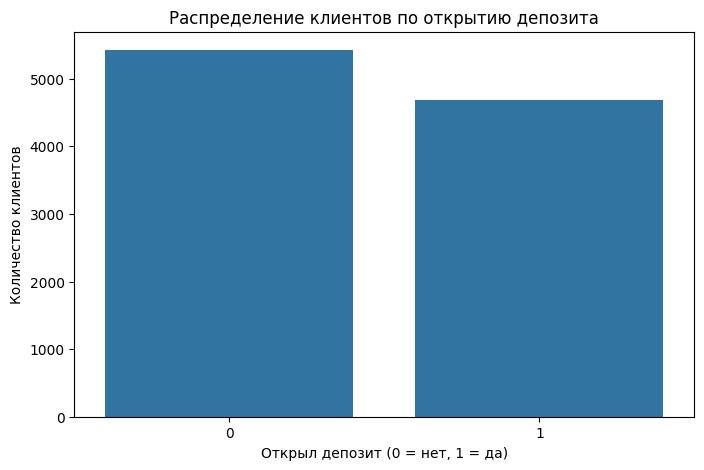

deposit
0    5424
1    4681
Name: count, dtype: int64

In [169]:
# изучите соотношение классов в ваших данных на предмет несбалансированности, проиллюстрируйте результат
# ваш код
df['deposit'] = df['deposit'].apply(lambda x: 1 if x == 'yes' else 0)
df['deposit'].value_counts()
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='deposit')
plt.title('Распределение клиентов по открытию депозита')
plt.xlabel('Открыл депозит (0 = нет, 1 = да)')
plt.ylabel('Количество клиентов')
plt.show()
df['deposit'].value_counts()

### Задания 2 и 3

In [170]:
#рассчитайте описательные статистики для количественных переменных, проинтерпретируйте результат
#ваш код
df['age'].describe()
df['duration'].describe()

count    10105.000000
mean       368.742603
std        346.651524
min          2.000000
25%        137.000000
50%        252.000000
75%        490.000000
max       3881.000000
Name: duration, dtype: float64

### Задания 4 и 5

In [171]:
#рассчитайте описательные статистики для категориальных переменных, проинтерпретируйте результат
#ваш код
#постройте визуализации, иллюстрирующие результаты
df.describe(include='object')


,job,marital,education,default,housing,loan,contact,month,poutcome
count,10105,10105,10105,10105,10105,10105,10105,10105,10105
unique,11,3,3,2,2,2,3,12,4
top,management,married,secondary,no,no,no,cellular,may,unknown
freq,2315,5715,5517,9939,5243,8712,7283,2617,7570


### Задание 6

Смотрим на данные poutcome:
poutcome
unknown    7570
failure    1109
success     945
other       481
Name: count, dtype: int64

Доля 'yes' для каждого статуса:
failure: 0.0% успеха (1109 клиентов)
success: 0.0% успеха (945 клиентов)
unknown: 0.0% успеха (7570 клиентов)
other: 0.0% успеха (481 клиентов)


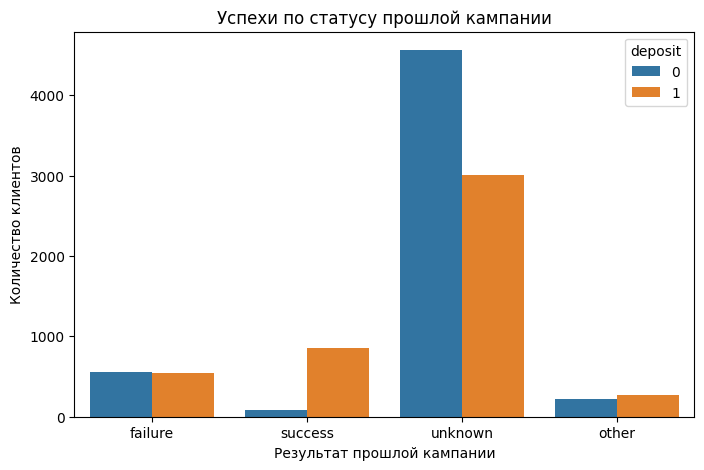

In [172]:
# Узнайте, для какого статуса предыдущей маркетинговой кампании успех в текущей превалирует над количеством неудач.
# ваш код
if 'poutcome' in df.columns:
	poutcome_pivot = df.groupby('poutcome')['deposit'].value_counts(normalize=True).unstack().fillna(0)
   
   
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Простая проверка
print("Смотрим на данные poutcome:")
print(df['poutcome'].value_counts())
print("\nДоля 'yes' для каждого статуса:")

# 2. Простой расчет процента успеха
for status in ['failure', 'success', 'unknown', 'other']:
    group = df[df['poutcome'] == status]
    if len(group) > 0:
        success_rate = (group['deposit'] == 'yes').mean() * 100
        print(f"{status}: {success_rate:.1f}% успеха ({len(group)} клиентов)")

# 3. Простой график
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='poutcome', hue='deposit', 
              order=['failure', 'success', 'unknown', 'other'])
plt.title('Успехи по статусу прошлой кампании')
plt.xlabel('Результат прошлой кампании')
plt.ylabel('Количество клиентов')
plt.show()

### Задание 7

Месяцы в данных: ['apr', 'aug', 'dec', 'feb', 'jan', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep']

Процент неудач по месяцам:
month
may    67.863966
jan    60.815047
jul    58.956276
nov    58.461538
aug    55.956679
jun    54.891304
feb    45.557123
apr    38.192771
oct    18.507463
sep    16.546763
mar    10.126582
dec     9.677419
Name: deposit, dtype: float64

Самый высокий процент неудач: 67.9% в месяце 'may'


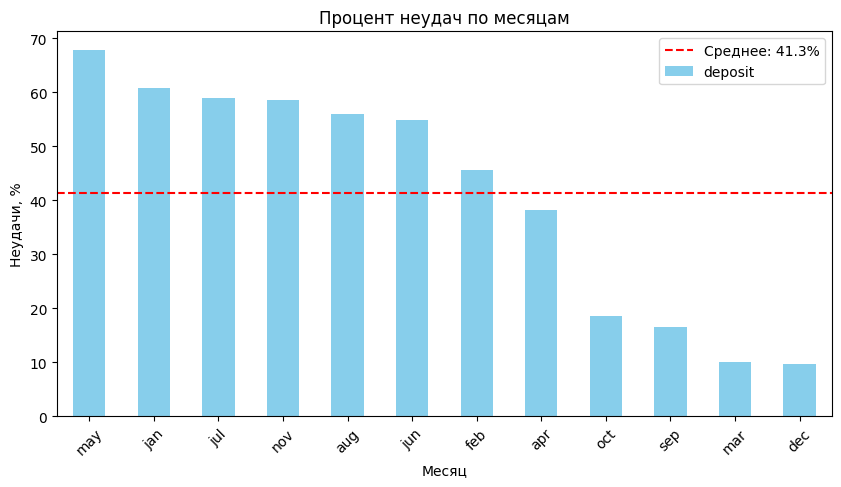

In [173]:
# узнайте, в каком месяце чаще всего отказывались от предложения открыть депозит
# ваш код
# Проверяем месяцы
print("Месяцы в данных:", sorted(df['month'].unique()))

# Считаем процент неудач (deposit=0)
result = df.groupby('month')['deposit'].apply(lambda x: (x == 0).mean() * 100).sort_values(ascending=False)

print("\nПроцент неудач по месяцам:")
print(result)

# Самый плохой месяц
worst_month = result.index[0]
worst_rate = result.iloc[0]
print(f"\nСамый высокий процент неудач: {worst_rate:.1f}% в месяце '{worst_month}'")

# Визуализация
plt.figure(figsize=(10, 5))
result.plot(kind='bar', color='skyblue')
plt.title('Процент неудач по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Неудачи, %')
plt.axhline(y=result.mean(), color='red', linestyle='--', label=f'Среднее: {result.mean():.1f}%')
plt.legend()
plt.xticks(rotation=45)
plt.show()

### Задание 8

In [174]:
# создайте возрастные группы и определите, в каких группах более склонны открывать депозит, чем отказываться от предложения
age_bins = [0, 30, 40, 50, 60, 100]
age_labels = ['<30', '30-40', '40-50', '50-60', '60+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, 
                         labels=age_labels, 
                         right=False,  # интервал [левая, правая)
                         include_lowest=True)
df['age_group_deposit'] = df.groupby('age_group')['deposit'].apply(lambda x: (x == 0).mean() * 100).sort_values(ascending=False)
result = df.groupby('month')['deposit'].apply(lambda x: (x == 0).mean() * 100).sort_values(ascending=False)
print("Распределение по возрастным группам:")
print(result.value_counts().sort_index())

Распределение по возрастным группам:
deposit
9.677419     1
10.126582    1
16.546763    1
18.507463    1
38.192771    1
45.557123    1
54.891304    1
55.956679    1
58.461538    1
58.956276    1
60.815047    1
67.863966    1
Name: count, dtype: int64


Анализ возрастных групп:

Процент открытия депозита по возрастным группам:
  60+: 76.0% успеха
  <30: 59.2% успеха
  30-40: 43.3% успеха
  50-60: 40.5% успеха
  40-50: 39.4% успеха

Группы, где успехов БОЛЬШЕ, чем неудач:
  ✓ 60+: 76.0% успеха (преобладают успехи)
  ✓ <30: 59.2% успеха (преобладают успехи)
  ✗ 30-40: 43.3% успеха (преобладают отказы)
  ✗ 50-60: 40.5% успеха (преобладают отказы)
  ✗ 40-50: 39.4% успеха (преобладают отказы)


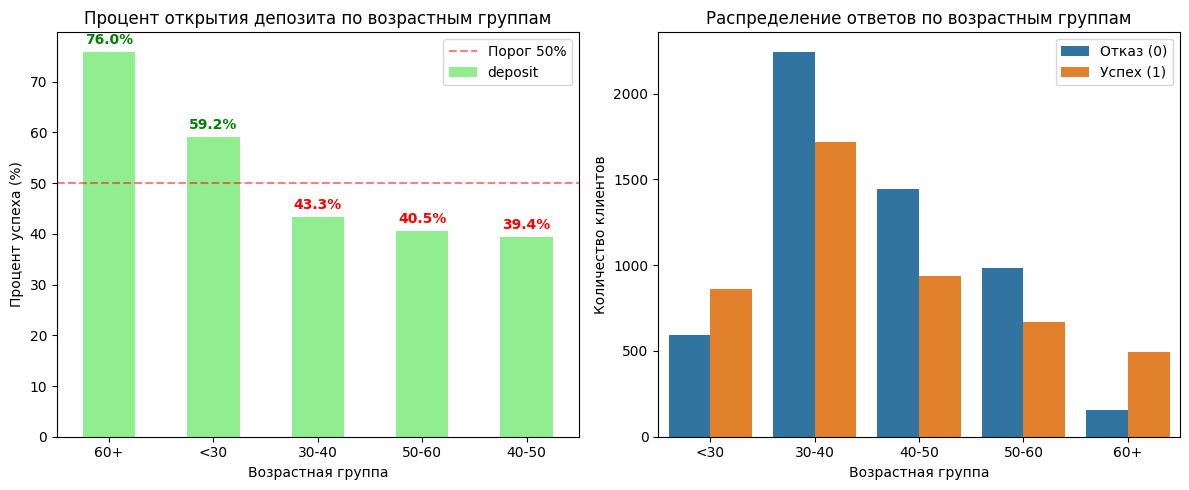

In [175]:
# 1. Создаем возрастные группы
age_bins = [0, 30, 40, 50, 60, 100]
age_labels = ['<30', '30-40', '40-50', '50-60', '60+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, 
                         labels=age_labels, 
                         right=False)

# 2. Анализируем склонность к открытию депозита
print("Анализ возрастных групп:\n")

# Считаем процент УСПЕХА (открыли депозит) для каждой группы
if df['deposit'].dtype == 'object':  # если 'yes'/'no'
    success_rate = df.groupby('age_group')['deposit'].apply(
        lambda x: (x == 'yes').mean() * 100
    )
else:  # если 0/1
    success_rate = df.groupby('age_group')['deposit'].apply(
        lambda x: x.mean() * 100
    )

# Сортируем по проценту успеха
success_rate = success_rate.sort_values(ascending=False)

print("Процент открытия депозита по возрастным группам:")
for age_group, rate in success_rate.items():
    print(f"  {age_group}: {rate:.1f}% успеха")

# 3. Определяем группы, где больше успехов, чем неудач
print("\nГруппы, где успехов БОЛЬШЕ, чем неудач:")
for age_group, rate in success_rate.items():
    if rate > 50:  # если успехов больше 50%
        print(f"  ✓ {age_group}: {rate:.1f}% успеха (преобладают успехи)")
    else:
        print(f"  ✗ {age_group}: {rate:.1f}% успеха (преобладают отказы)")

# 4. Визуализация
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# График 1: Процент успеха
plt.subplot(1, 2, 1)
success_rate.plot(kind='bar', color='lightgreen')
plt.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='Порог 50%')
plt.title('Процент открытия депозита по возрастным группам')
plt.xlabel('Возрастная группа')
plt.ylabel('Процент успеха (%)')
plt.xticks(rotation=0)
plt.legend()

# Добавляем значения на столбцы
for i, v in enumerate(success_rate):
    color = 'green' if v > 50 else 'red'
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', color=color, fontweight='bold')

# График 2: Распределение ответов
plt.subplot(1, 2, 2)
if df['deposit'].dtype == 'object':
    df['deposit_binary'] = df['deposit'].map({'yes': 1, 'no': 0})
    hue_col = 'deposit_binary'
else:
    hue_col = 'deposit'

sns.countplot(data=df, x='age_group', hue=hue_col, order=age_labels)
plt.title('Распределение ответов по возрастным группам')
plt.xlabel('Возрастная группа')
plt.ylabel('Количество клиентов')
plt.legend(['Отказ (0)', 'Успех (1)'])

plt.tight_layout()
plt.show()



### Задания 9 и 10

In [176]:
def create_deposit_summary(df, category_col):
    # Создаем таблицу с абсолютными значениями
    abs_table = pd.crosstab(df[category_col], df['deposit'])
    abs_table = abs_table.rename(columns={1: 'Открыли депозит', 0: 'Не открыли депозит'})
    
    # Создаем таблицу с процентами
    perc_table = pd.crosstab(df[category_col], df['deposit'], normalize='index') * 100
    perc_table = perc_table.rename(columns={1: 'Процент открывших', 0: 'Процент не открывших'})
    
    # Объединяем таблицы
    result = pd.concat([abs_table, perc_table], axis=1)
    result = result[['Открыли депозит', 'Не открыли депозит', 'Процент открывших']]
    result['Всего клиентов'] = df[category_col].value_counts()
    
    # Сортируем по проценту открывших
    return result.sort_values('Процент открывших', ascending=False).round(1)

# Создаем таблицы для всех категорий
job_analysis = create_deposit_summary(df, 'job')
marital_analysis = create_deposit_summary(df, 'marital')
education_analysis = create_deposit_summary(df, 'education')

# Выводим результаты
print("Анализ по сфере занятости:")
print(job_analysis)
print("\nАнализ по семейному положению:")
print(marital_analysis)
print("\nАнализ по образованию:")
print(education_analysis)

Анализ по сфере занятости:
deposit        Открыли депозит  Не открыли депозит  Процент открывших  \
job                                                                     
student                    245                  81               75.2   
retired                    432                 231               65.2   
unemployed                 189                 143               56.9   
management                1135                1180               49.0   
admin.                     574                 672               46.1   
technician                 738                 900               45.1   
self-employed              161                 197               45.0   
services                   345                 523               39.7   
housemaid                   99                 153               39.3   
entrepreneur               111                 189               37.0   
blue-collar                652                1155               36.1   

deposit        Всего кл

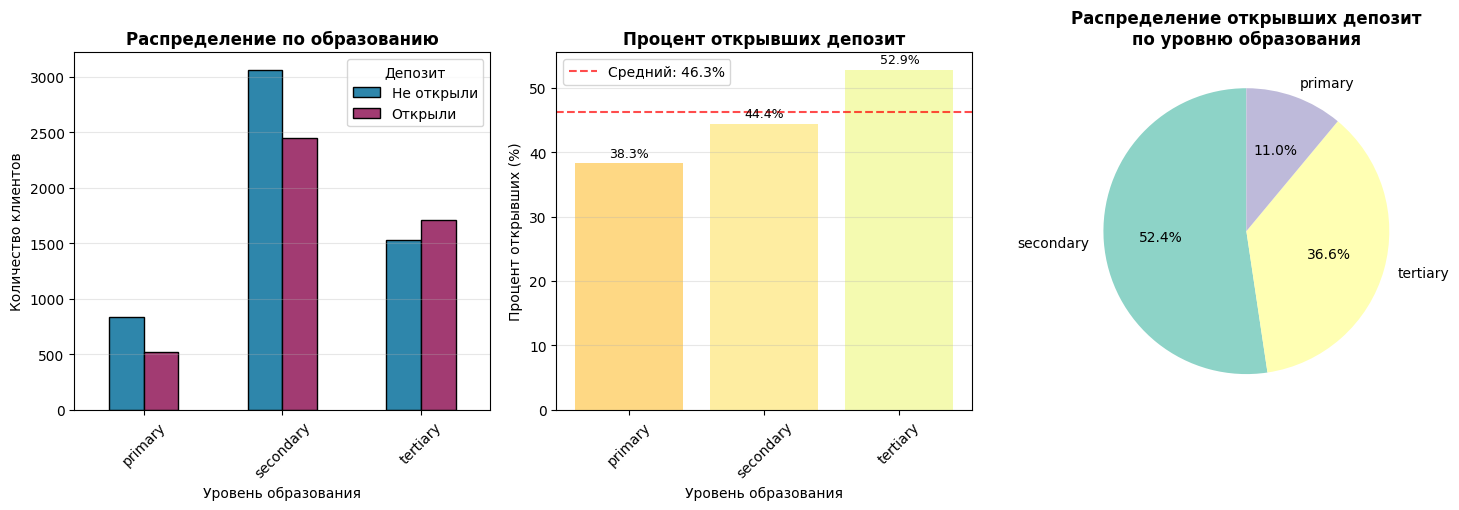

In [177]:
# Построение визуализаций для открывших и неоткрывших депозит по образованию
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Создаем crosstab для образования
edu_crosstab = pd.crosstab(df['education'], df['deposit'])
edu_crosstab = edu_crosstab.rename(columns={1: 'Открыли', 0: 'Не открыли'})

# 1. Столбчатая диаграмма сравнения
edu_crosstab.plot(kind='bar', ax=axes[0], color=['#2E86AB', '#A23B72'], edgecolor='black')
axes[0].set_title('Распределение по образованию', fontweight='bold')
axes[0].set_xlabel('Уровень образования')
axes[0].set_ylabel('Количество клиентов')
axes[0].legend(title='Депозит')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# 2. Процент открывших (столбчатая диаграмма)
edu_percent = df.groupby('education')['deposit'].mean() * 100
axes[1].bar(range(len(edu_percent)), edu_percent.values, 
            color=plt.cm.RdYlGn(edu_percent.values/100))
axes[1].set_title('Процент открывших депозит', fontweight='bold')
axes[1].set_xlabel('Уровень образования')
axes[1].set_ylabel('Процент открывших (%)')
axes[1].set_xticks(range(len(edu_percent)))
axes[1].set_xticklabels(edu_percent.index, rotation=45)
axes[1].axhline(y=df['deposit'].mean()*100, color='red', linestyle='--', 
                alpha=0.7, label=f'Средний: {df["deposit"].mean()*100:.1f}%')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for i, percent in enumerate(edu_percent.values):
    axes[1].text(i, percent + 1, f'{percent:.1f}%', ha='center', fontsize=9)

# 3. Круговая диаграмма распределения открывших
deposit_by_edu = df[df['deposit'] == 1]['education'].value_counts()
axes[2].pie(deposit_by_edu.values, labels=deposit_by_edu.index, 
            autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3.colors)
axes[2].set_title('Распределение открывших депозит\nпо уровню образования', fontweight='bold')

plt.tight_layout()
plt.show()


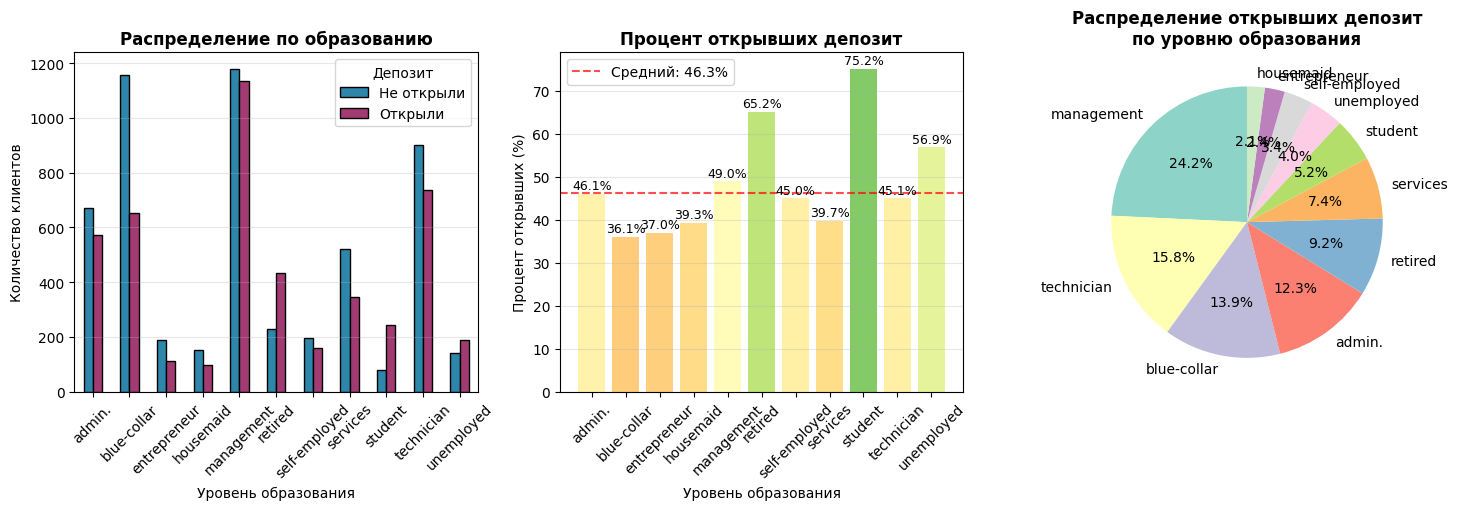

In [178]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от вида профессиональной занятости
# Построение визуализаций для открывших и неоткрывших депозит по образованию
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Создаем crosstab для образования
edu_crosstab = pd.crosstab(df['job'], df['deposit'])
edu_crosstab = edu_crosstab.rename(columns={1: 'Открыли', 0: 'Не открыли'})

# 1. Столбчатая диаграмма сравнения
edu_crosstab.plot(kind='bar', ax=axes[0], color=['#2E86AB', '#A23B72'], edgecolor='black')
axes[0].set_title('Распределение по образованию', fontweight='bold')
axes[0].set_xlabel('Уровень образования')
axes[0].set_ylabel('Количество клиентов')
axes[0].legend(title='Депозит')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# 2. Процент открывших (столбчатая диаграмма)
edu_percent = df.groupby('job')['deposit'].mean() * 100
axes[1].bar(range(len(edu_percent)), edu_percent.values, 
            color=plt.cm.RdYlGn(edu_percent.values/100))
axes[1].set_title('Процент открывших депозит', fontweight='bold')
axes[1].set_xlabel('Уровень образования')
axes[1].set_ylabel('Процент открывших (%)')
axes[1].set_xticks(range(len(edu_percent)))
axes[1].set_xticklabels(edu_percent.index, rotation=45)
axes[1].axhline(y=df['deposit'].mean()*100, color='red', linestyle='--', 
                alpha=0.7, label=f'Средний: {df["deposit"].mean()*100:.1f}%')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for i, percent in enumerate(edu_percent.values):
    axes[1].text(i, percent + 1, f'{percent:.1f}%', ha='center', fontsize=9)

# 3. Круговая диаграмма распределения открывших
deposit_by_edu = df[df['deposit'] == 1]['job'].value_counts()
axes[2].pie(deposit_by_edu.values, labels=deposit_by_edu.index, 
            autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3.colors)
axes[2].set_title('Распределение открывших депозит\nпо уровню образования', fontweight='bold')

plt.tight_layout()
plt.show()

### Задание 11

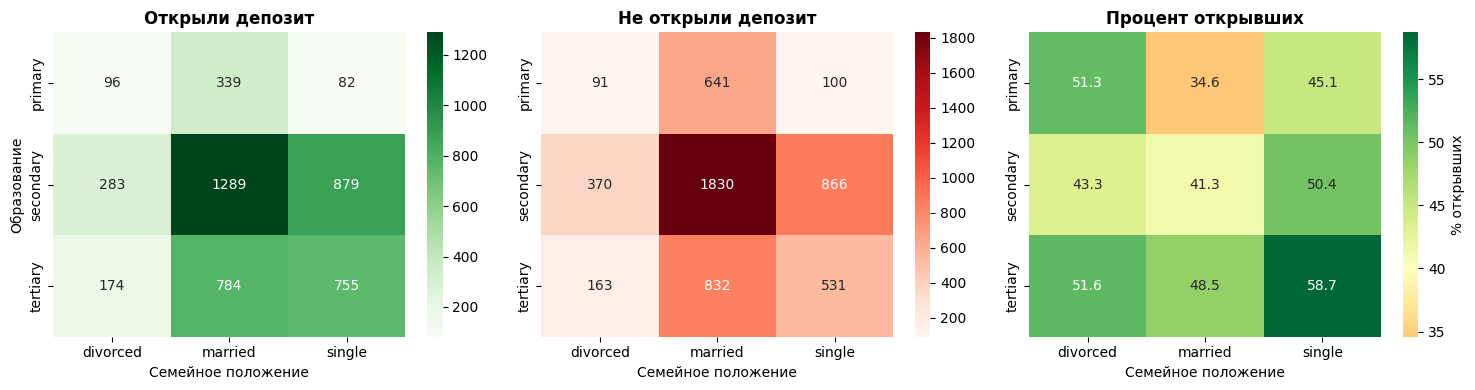

ОТВЕТ НА ВОПРОС:

1. Одинокие с высшим образованием: 755 человек
2. Разведенные с низким образованием: 96 человек

→ Одиноких с высшим образованием БОЛЬШЕ на 659 человек

КЛЮЧЕВЫЕ ВЫВОДЫ:

1. Наиболее популярные среди открывших депозит:
   • secondary + married: 1289 человек
   • secondary + single: 879 человек

2. Наиболее популярные среди не открывших:
   • secondary + married: 1830 человек
   • secondary + single: 866 человек

3. Самые успешные комбинации (по %):
   • tertiary + single: 58.7%
   • tertiary + divorced: 51.6%


In [179]:
# Разделяем данные
df_yes = df[df['deposit'] == 1]
df_no = df[df['deposit'] == 0]

# Создаем сводные таблицы
pivot_yes = pd.crosstab(df_yes['education'], df_yes['marital'])
pivot_no = pd.crosstab(df_no['education'], df_no['marital'])

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Открыли депозит
sns.heatmap(pivot_yes, annot=True, fmt='d', cmap='Greens', ax=axes[0])
axes[0].set_title('Открыли депозит', fontweight='bold')
axes[0].set_xlabel('Семейное положение')
axes[0].set_ylabel('Образование')

# 2. Не открыли депозит
sns.heatmap(pivot_no, annot=True, fmt='d', cmap='Reds', ax=axes[1])
axes[1].set_title('Не открыли депозит', fontweight='bold')
axes[1].set_xlabel('Семейное положение')
axes[1].set_ylabel('')

# 3. Процент успеха
pivot_rate = (pivot_yes / (pivot_yes + pivot_no) * 100).fillna(0)
sns.heatmap(pivot_rate, annot=True, fmt='.1f', cmap='RdYlGn', center=40, 
            ax=axes[2], cbar_kws={'label': '% открывших'})
axes[2].set_title('Процент открывших', fontweight='bold')
axes[2].set_xlabel('Семейное положение')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

# Ответ на вопрос
print("="*60)
print("ОТВЕТ НА ВОПРОС:")
print("="*60)

# Сравниваем: одинокие с высшим vs разведенные с низким
single_higher = pivot_yes.loc['tertiary', 'single'] if 'tertiary' in pivot_yes.index else 0
divorced_lower = pivot_yes.loc['primary', 'divorced'] if 'primary' in pivot_yes.index else 0

print(f"\n1. Одинокие с высшим образованием: {single_higher} человек")
print(f"2. Разведенные с низким образованием: {divorced_lower} человек")

if single_higher > divorced_lower:
    print(f"\n→ Одиноких с высшим образованием БОЛЬШЕ на {single_higher - divorced_lower} человек")
else:
    print(f"\n→ Разведенных с низким образованием БОЛЬШЕ на {divorced_lower - single_higher} человек")

# Ключевые выводы
print("\n" + "="*60)
print("КЛЮЧЕВЫЕ ВЫВОДЫ:")
print("="*60)

print("\n1. Наиболее популярные среди открывших депозит:")
top_yes = pivot_yes.stack().nlargest(2)
for (edu, marital), count in top_yes.items():
    print(f"   • {edu} + {marital}: {count} человек")

print("\n2. Наиболее популярные среди не открывших:")
top_no = pivot_no.stack().nlargest(2)
for (edu, marital), count in top_no.items():
    print(f"   • {edu} + {marital}: {count} человек")

print("\n3. Самые успешные комбинации (по %):")
success_rate = (pivot_yes / (pivot_yes + pivot_no) * 100).fillna(0)
top_rate = success_rate.stack().nlargest(2)
for (edu, marital), rate in top_rate.items():
    print(f"   • {edu} + {marital}: {rate:.1f}%")

## Часть 3: преобразование данных

### Задание 1

In [180]:
# преобразуйте уровни образования
label_encoder = LabelEncoder()
df['education'] = label_encoder.fit_transform(df['education'])
df['education'].sum()
df['age'] = label_encoder.fit_transform(df['age_group'])
df['age'].sum()

np.int64(13469)

In [181]:
df = df.drop(['age_group', 'age_group_deposit'], axis=1)


### Задания 2 и 3

In [182]:
# преобразуйте бинарные переменные в представление из нулей и единиц
df['deposit'].describe()
listing = ['default', 'housing', 'loan']
arif = []
suming = 0
for i in listing:
   mir = df[i].apply(lambda x: 1 if x == 'yes' else 0)
   arif.append(mir.mean())
for z in arif:
   suming += z
round(suming, 3)
df['default'] = df['default'].apply(lambda x: 1 if x == 'yes' else 0)
df['housing']= df['housing'].apply(lambda x: 1 if x == 'yes' else 0)
df['loan'] = df['loan'].apply(lambda x: 1 if x == 'yes' else 0)

### Задание 4

In [183]:
# Правильный синтаксис
dummies = pd.get_dummies(df[['job','marital','contact','month','poutcome']], 
                         prefix=['job','marital','contact','month','poutcome'])

# Удаляем оригинальные категориальные столбцы
d = df.drop(['job', 'marital', 'contact', 'month', 'poutcome'], axis=1)

# Правильное объединение: передаем список DataFrame'ов
df = pd.concat([d, dummies], axis=1)  # ВАЖНО: [d, dummies] в квадратных скобках

In [184]:
bool_columns = df.select_dtypes(include=['bool']).columns
df[bool_columns] = df[bool_columns].astype(int)
df

,age,education,default,balance,housing,loan,day,duration,campaign,pdays,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,2,1,0,2343.0,1,0,5,1042,1,-1,...,0,0,1,0,0,0,0,0,0,1
1,2,1,0,45.0,0,0,5,1467,1,-1,...,0,0,1,0,0,0,0,0,0,1
2,1,1,0,1270.0,1,0,5,1389,1,-1,...,0,0,1,0,0,0,0,0,0,1
3,2,1,0,2476.0,1,0,5,579,1,-1,...,0,0,1,0,0,0,0,0,0,1
4,2,2,0,184.0,0,0,5,673,2,-1,...,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10100,0,0,0,1.0,1,0,20,257,1,-1,...,0,0,0,0,0,0,0,0,0,1
10101,0,1,0,733.0,0,0,16,83,4,-1,...,1,0,0,0,0,0,0,0,0,1
10102,0,1,0,29.0,0,0,19,156,2,-1,...,0,0,0,0,0,0,0,0,0,1
10103,1,1,0,0.0,0,1,8,9,2,172,...,0,0,1,0,0,0,1,0,0,0


### Задания 5 и 6

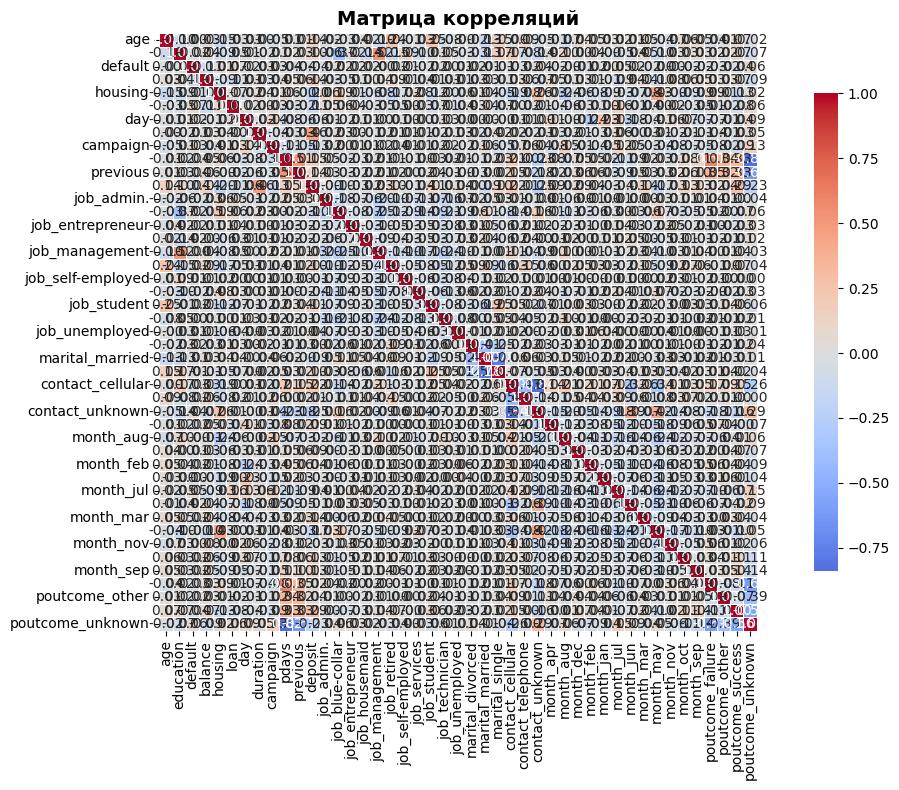

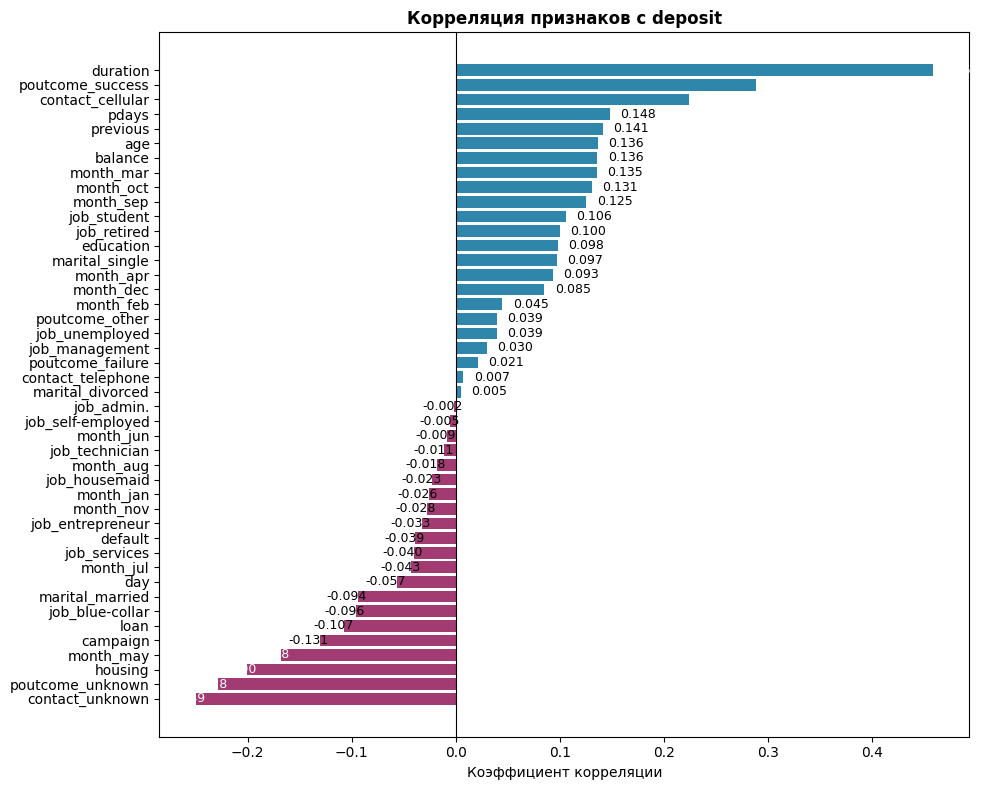

ПРИЗНАКИ С КОРРЕЛЯЦИЕЙ > 0.7:
pdays ↔ poutcome_unknown: -0.824
marital_married ↔ marital_single: -0.779
contact_cellular ↔ contact_unknown: -0.838


In [185]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Преобразуем булевы столбцы в int
df = df.astype({col: 'int8' for col in df.select_dtypes(include=['bool']).columns})

# 2. Матрица корреляций
corr = df.corr()

# 3. Тепловая карта
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Матрица корреляций', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Корреляция с deposit
deposit_corr = corr['deposit'].drop('deposit').sort_values()

# 5. Столбчатая диаграмма
plt.figure(figsize=(10, 8))
bars = plt.barh(range(len(deposit_corr)), deposit_corr.values,
                color=['#2E86AB' if x > 0 else '#A23B72' for x in deposit_corr.values])
plt.yticks(range(len(deposit_corr)), deposit_corr.index)
plt.xlabel('Коэффициент корреляции')
plt.title('Корреляция признаков с deposit', fontweight='bold')
plt.axvline(x=0, color='black', linewidth=0.8)

# Добавляем значения
for i, (bar, val) in enumerate(zip(bars, deposit_corr.values)):
    plt.text(val + (0.01 if val >= 0 else -0.03), bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9,
             color='white' if abs(val) > 0.15 else 'black')

plt.tight_layout()
plt.show()

# 6. Анализ мультиколлинеарности
print("ПРИЗНАКИ С КОРРЕЛЯЦИЕЙ > 0.7:")
high_corr = [(corr.columns[i], corr.columns[j], corr.iloc[i,j]) 
             for i in range(len(corr)) for j in range(i+1, len(corr)) 
             if abs(corr.iloc[i,j]) > 0.7]

if high_corr:
    for col1, col2, val in high_corr:
        print(f"{col1} ↔ {col2}: {val:.3f}")
else:
    print("Сильной мультиколлинеарности не обнаружено")

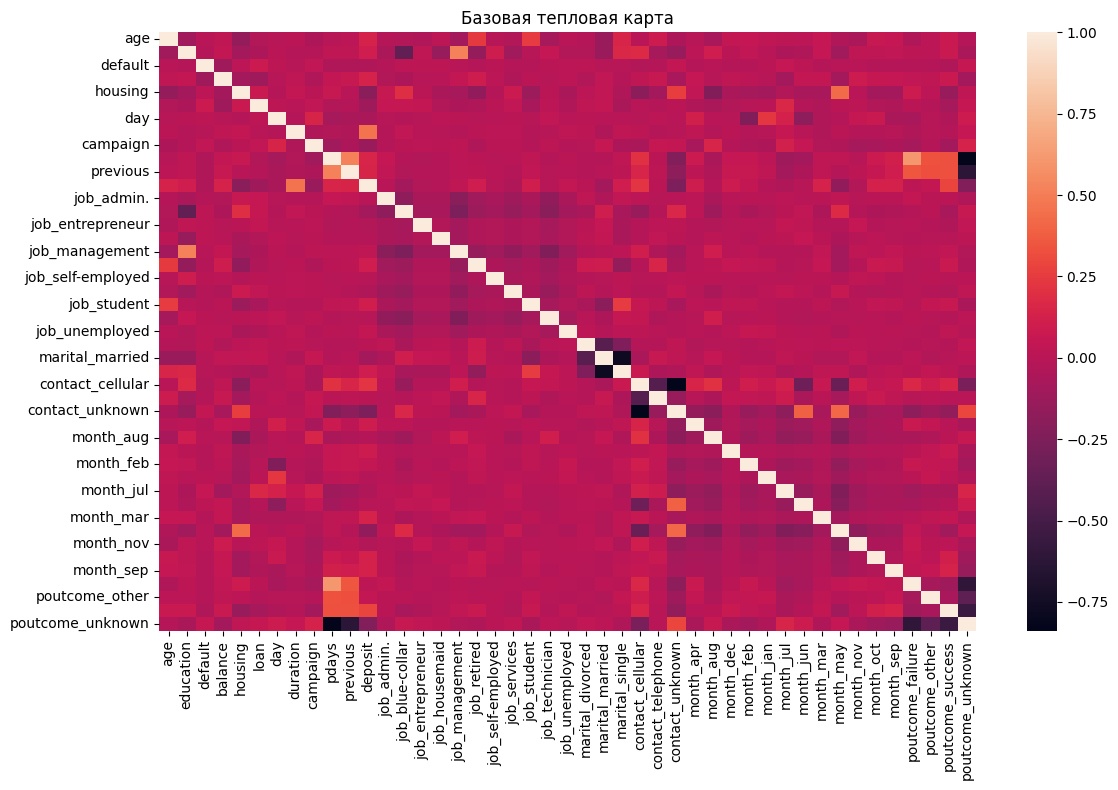

In [186]:
%matplotlib inline
import seaborn as sns
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr())
plt.title('Базовая тепловая карта')
plt.tight_layout()
plt.show()

### Задания 7 и 8

In [187]:
X = df.drop(['deposit'], axis=1)
y = df['deposit']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.33)
print(f'Train shape:', X_train.shape)
print(f'Test shape:', X_test.shape)

print('Cреднее значение целевой переменной на тестовой выборке? Train - 1')
print('Train:\n', y_train.value_counts(normalize=True), sep='')
print('Valid:\n', y_test.value_counts(normalize=True), sep='')

Train shape: (6770, 44)
Test shape: (3335, 44)
Cреднее значение целевой переменной на тестовой выборке? Train - 1
Train:
deposit
0    0.53678
1    0.46322
Name: proportion, dtype: float64
Valid:
deposit
0    0.536732
1    0.463268
Name: proportion, dtype: float64


### Задание 9

In [188]:
from sklearn.feature_selection import SelectKBest, f_classif
import pandas as pd

# 1) Подготовка данных: числовые признаки за исключением целевой 'deposit'
numeric_features = df.drop('deposit', axis=1).select_dtypes(
    include=['int64','int32','int16','int8','float64','float32','bool']
).columns.tolist()

X_df = df[numeric_features].copy()

# 2) Целевая переменная
if df['deposit'].dtype == 'object':
    y = df['deposit'].map({'yes': 1, 'no': 0})
elif df['deposit'].dtype == 'bool':
    y = df['deposit'].astype(int)
else:
    y = df['deposit']

# 3) Отбор 15 лучших признаков (или меньше, если признаков меньше 15)
k = min(15, len(numeric_features))
selector = SelectKBest(score_func=f_classif, k=k)
selector.fit(X_df, y)

# 4) Результаты отбора
selected_mask = selector.get_support()
selected_features = X_df.columns[selected_mask].tolist()
scores = selector.scores_[selected_mask]
pvalues = selector.pvalues_[selected_mask]

results_df = pd.DataFrame({
    'Признак': selected_features,
    'F-статистика': scores,
    'p-value': pvalues
}).sort_values('F-статистика', ascending=False)

print(results_df.to_string(index=False))

         Признак  F-статистика       p-value
        duration   2679.087769  0.000000e+00
poutcome_success    917.176721 6.376059e-193
 contact_unknown    669.483805 5.492731e-143
poutcome_unknown    555.534356 1.280884e-119
contact_cellular    533.428758 4.683261e-115
         housing    422.229916  5.957952e-92
       month_may    294.159482  5.113623e-65
           pdays    225.992277  1.566736e-50
        previous    205.233847  4.253428e-46
             age    191.080180  4.551065e-43
         balance    190.080810  7.450949e-43
       month_mar    188.532492  1.599432e-42
        campaign    175.602766  9.482183e-40
       month_oct    175.309186  1.096285e-39
       month_sep    160.988809  1.308079e-36


### Задание 10

In [189]:
# selected_features — список из 15 признаков, выбранных SelectKBest
X_train_selected = X_train[selected_features]
X_test_selected  = X_test[selected_features]

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled  = scaler.transform(X_test_selected)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=selected_features, index=X_train.index)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=selected_features, index=X_test.index)

# 8. Проверка результатов нормализации
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ НОРМАЛИЗАЦИИ ОТОБРАННЫХ ПРИЗНАКОВ")
print("="*60)

print("\nДиапазоны значений до нормализации (train):")
print(f"  Min: {X_train.min().min():.4f}")
print(f"  Max: {X_train.max().max():.4f}")

print("\nДиапазоны значений после нормализации:")
print(f"  Train min: {X_train_scaled_df.min().min():.4f}")
print(f"  Train max: {X_train_scaled_df.max().max():.4f}")
print(f"  Test min:  {X_test_scaled_df.min().min():.4f}")
print(f"  Test max:  {X_test_scaled_df.max().max():.4f}")

# 9. Создаем финальные нормализованные DataFrame
train_final = pd.concat([X_train_scaled_df, y_train], axis=1)
test_final = pd.concat([X_test_scaled_df, y_test], axis=1)

print(f"\nФинальные размеры:")
print(f"  Train set: {train_final.shape}")
print(f"  Test set:  {test_final.shape}")

# 10. Пример нормализованных данных
print("\nПример нормализованных данных (первые 3 строки):")
print(train_final.head(3))


РЕЗУЛЬТАТЫ НОРМАЛИЗАЦИИ ОТОБРАННЫХ ПРИЗНАКОВ

Диапазоны значений до нормализации (train):
  Min: -2049.0000
  Max: 4063.0000

Диапазоны значений после нормализации:
  Train min: 0.0000
  Train max: 1.0000
  Test min:  0.0000
  Test max:  1.0000

Финальные размеры:
  Train set: (6770, 16)
  Test set:  (3335, 16)

Пример нормализованных данных (первые 3 строки):
      age   balance  housing  duration  campaign     pdays  previous  \
6542  0.0  0.426374      1.0  0.131735   0.00000  0.000000  0.000000   
4230  0.0  0.346531      0.0  0.075793   0.00000  0.240936  0.034483   
5079  0.0  0.335242      1.0  0.102346   0.02381  0.419883  0.086207   

      contact_cellular  contact_unknown  month_mar  month_may  month_oct  \
6542               1.0              0.0        0.0        0.0        0.0   
4230               1.0              0.0        0.0        0.0        0.0   
5079               0.0              0.0        0.0        1.0        0.0   

      month_sep  poutcome_success  poutcom

In [190]:
import numpy as np

# Если у вас есть DataFrame с нормализованными тестовыми данными
if 'X_test_scaled_df' in locals():
    first_predictor_mean = X_test_scaled_df.iloc[:, 1].mean()      
print(f"Среднее первого предиктора = {first_predictor_mean:.2f}")


Среднее первого предиктора = 0.47


# Часть 4: Решение задачи классификации: логистическая регрессия и решающие деревья

### Задание 1

In [191]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
base_model = LogisticRegression(
    solver='sag',       # Алгоритм оптимизации
    max_iter=1000,      # Количество итераций
    random_state=42,    # Seed для воспроизводимости
    n_jobs=-1           # Использовать все ядра процессора
)
base_model.fit(X_train_scaled, y_train)

y_pred = base_model.predict(X_test_scaled)
y_pred_proba = base_model.predict_proba(X_test_scaled)[:, 1]

# 9. Вычисляем метрики качества
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "="*60)
print("ОЦЕНКА КАЧЕСТВА НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*60)

print(f"\nAccuracy (точность):  {accuracy:.3f}")
print(f"Precision (точность): {precision:.4f}")
print(f"Recall (полнота):     {recall:.4f}")
print(f"F1-score:             {f1:.4f}")
print(f"ROC-AUC:              {roc_auc:.4f}")


ОЦЕНКА КАЧЕСТВА НА ТЕСТОВОЙ ВЫБОРКЕ

Accuracy (точность):  0.805
Precision (точность): 0.8253
Recall (полнота):     0.7340
F1-score:             0.7770
ROC-AUC:              0.8879


In [192]:
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.linear_model import LogisticRegression # обучите логистическую регрессию и рассчитайте метрики качества

# 2. Создаем базовую модель логистической регрессии
base_model = LogisticRegression(
    solver='sag',       # Алгоритм оптимизации
    max_iter=1000,      # Количество итераций
    random_state=42,    # Seed для воспроизводимости
    n_jobs=-1           # Использовать все ядра процессора
)

# 3. Определяем гиперпараметры для GridSearch
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Параметр регуляризации
    'penalty': ['l2'],  # Для 'sag' поддерживается только l2
    'class_weight': [None, 'balanced']  # Балансировка классов
}

# 4. Создаем GridSearchCV
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,               # 5-кратная кросс-валидация
    scoring='accuracy',  # Метрика для оптимизации
    n_jobs=-1,          # Параллельные вычисления
    verbose=1,          # Вывод прогресса
    return_train_score=True
)

# 5. Обучаем модель с GridSearchCV
print("\nЗапуск GridSearchCV...")
grid_search.fit(X_train_scaled, y_train)

# 6. Выводим результаты GridSearch
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ GRIDSEARCHCV")
print("="*60)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучшая точность (кросс-валидация): {grid_search.best_score_:.4f}")

# 7. Создаем итоговую модель с лучшими параметрами
best_model = grid_search.best_estimator_

# 8. Оцениваем на тестовой выборке
y_pred = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# 9. Вычисляем метрики качества
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "="*60)
print("ОЦЕНКА КАЧЕСТВА НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*60)

print(f"\nAccuracy (точность):  {accuracy:.4f}")
print(f"Precision (точность): {precision:.4f}")
print(f"Recall (полнота):     {recall:.4f}")
print(f"F1-score:             {f1:.4f}")
print(f"ROC-AUC:              {roc_auc:.4f}")



Запуск GridSearchCV...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

РЕЗУЛЬТАТЫ GRIDSEARCHCV

Лучшие параметры: {'C': 100, 'class_weight': 'balanced', 'penalty': 'l2'}
Лучшая точность (кросс-валидация): 0.8300

ОЦЕНКА КАЧЕСТВА НА ТЕСТОВОЙ ВЫБОРКЕ

Accuracy (точность):  0.8126
Precision (точность): 0.8104
Recall (полнота):     0.7773
F1-score:             0.7935
ROC-AUC:              0.8898


### Задания 2,3,4

In [193]:
# обучите решающие деревья, настройте максимальную глубину
from sklearn import tree #модели деревьев решения
import numpy as np
from sklearn.linear_model import LogisticRegression # обучите логистическую регрессию и рассчитайте метрики качества

# 2. Создаем базовую модель логистической регрессии
#Создаём объект класса DecisionTreeClassifier
base_model = tree.DecisionTreeClassifier(
    criterion='entropy', 
    random_state=42
)

# 5. Обучаем модель с GridSearchCV
print("\nЗапуск DecisionTreeClassifier...")
base_model.fit(X_train_scaled, y_train)

# 7. Создаем итоговую модель с лучшими параметрами

# 8. Оцениваем на тестовой выборке
y_pred = base_model.predict(X_test_scaled)
y_pred_proba = base_model.predict_proba(X_test_scaled)[:, 1]

# 9. Вычисляем метрики качества
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "="*60)
print("ОЦЕНКА КАЧЕСТВА НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*60)

print(f"\nAccuracy (точность):  {accuracy:.4f}")
print(f"Precision (точность): {precision:.4f}")
print(f"Recall (полнота):     {recall:.4f}")
print(f"F1-score:             {f1:.4f}")
print(f"ROC-AUC:              {roc_auc:.4f}")


Запуск DecisionTreeClassifier...

ОЦЕНКА КАЧЕСТВА НА ТЕСТОВОЙ ВЫБОРКЕ

Accuracy (точность):  0.7475
Precision (точность): 0.7357
Recall (полнота):     0.7100
F1-score:             0.7227
ROC-AUC:              0.7450


Оптимальная глубина (с учетом переобучения): 7
Accuracy на тесте при этой глубине: 0.8183

Простой критерий (до полного запоминания): 7


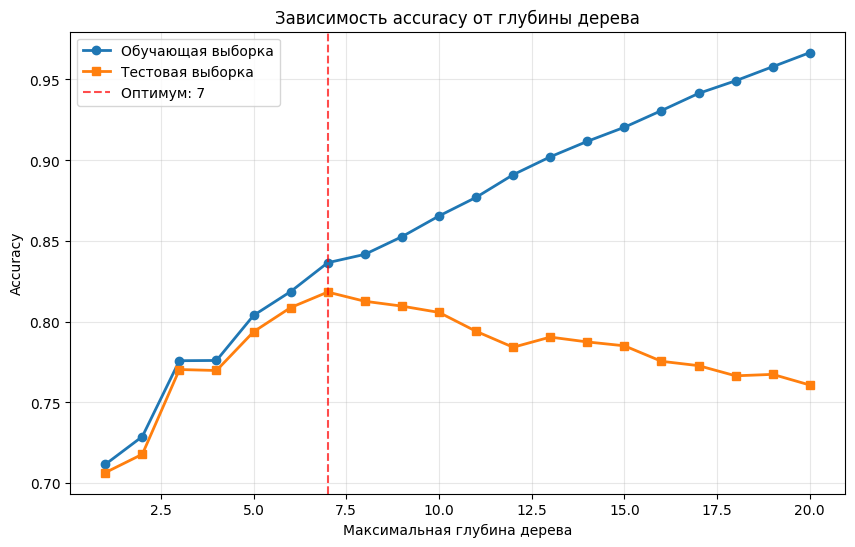


Глубина    Train Accuracy  Test Accuracy   Разница   
1          0.7115          0.7064          0.0051     
2          0.7288          0.7178          0.0110     
3          0.7758          0.7703          0.0055     
4          0.7759          0.7697          0.0062     
5          0.8038          0.7937          0.0101     
6          0.8186          0.8087          0.0099     
7          0.8365          0.8183          0.0182     ← ОПТИМУМ
8          0.8417          0.8126          0.0291     
9          0.8526          0.8096          0.0430     
10         0.8654          0.8057          0.0597     
11         0.8770          0.7940          0.0830     
12         0.8910          0.7841          0.1069     
13         0.9021          0.7904          0.1117     
14         0.9117          0.7874          0.1243     
15         0.9204          0.7850          0.1354     
16         0.9307          0.7754          0.1553     
17         0.9414          0.7727          0.1686     
1

In [194]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Создаем или загружаем данные


# 2. Диапазон глубин для перебора
max_depths = range(1, 21)
train_scores = []
test_scores = []

# 3. Перебираем глубины
for depth in max_depths:
    # Создаем и обучаем модель с указанной глубиной
    model = DecisionTreeClassifier(
        max_depth=depth,  # КРИТИЧЕСКИ ВАЖНО: передаем depth!
        criterion='entropy', 
        random_state=42
    )

    model.fit(X_train_scaled, y_train)
    
    # Оценка на обучающей и тестовой выборках
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    train_scores.append(accuracy_score(y_train, y_train_pred))
    test_scores.append(accuracy_score(y_test, y_test_pred))

# 4. Находим оптимальную глубину
optimal_depth = None
max_test_score = 0

for i, depth in enumerate(max_depths):
    test_score = test_scores[i]
    train_score = train_scores[i]
    
    # Условия для оптимальной глубины:
    # 1. Максимальная accuracy на тесте
    # 2. Нет роста accuracy на обучении при ухудшении на тесте
    if test_score > max_test_score:
        # Проверяем, нет ли переобучения
        if i > 0:
            # Если accuracy на обучении растет, а на тесте не растет или падает - это переобучение
            if not (train_scores[i] > train_scores[i-1] and test_scores[i] <= test_scores[i-1]):
                max_test_score = test_score
                optimal_depth = depth
        else:
            max_test_score = test_score
            optimal_depth = depth

# 5. Более простой критерий: максимальная accuracy на тесте до момента,
# когда accuracy на обучении достигает 1.0 (полное запоминание)
simple_optimal_depth = None
for i, depth in enumerate(max_depths):
    if train_scores[i] >= 0.999:  # Практически полное запоминание
        # Ищем максимальную accuracy на тесте до этой глубины
        test_scores_before = test_scores[:i+1]
        optimal_idx = np.argmax(test_scores_before)
        simple_optimal_depth = max_depths[optimal_idx]
        break

if simple_optimal_depth is None:
    simple_optimal_depth = max_depths[np.argmax(test_scores)]

print(f"Оптимальная глубина (с учетом переобучения): {optimal_depth}")
print(f"Accuracy на тесте при этой глубине: {max_test_score:.4f}")
print(f"\nПростой критерий (до полного запоминания): {simple_optimal_depth}")

# 6. Визуализация
plt.figure(figsize=(10, 6))
plt.plot(max_depths, train_scores, 'o-', label='Обучающая выборка', linewidth=2)
plt.plot(max_depths, test_scores, 's-', label='Тестовая выборка', linewidth=2)
plt.axvline(x=optimal_depth, color='red', linestyle='--', alpha=0.7, label=f'Оптимум: {optimal_depth}')
plt.xlabel('Максимальная глубина дерева')
plt.ylabel('Accuracy')
plt.title('Зависимость accuracy от глубины дерева')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7. Вывод таблицы результатов
print("\n" + "="*60)
print(f"{'Глубина':<10} {'Train Accuracy':<15} {'Test Accuracy':<15} {'Разница':<10}")
print("="*60)
for i, depth in enumerate(max_depths):
    diff = train_scores[i] - test_scores[i]
    mark = "← ОПТИМУМ" if depth == optimal_depth else ""
    print(f"{depth:<10} {train_scores[i]:<15.4f} {test_scores[i]:<15.4f} {diff:<10.4f} {mark}")

### Задание 5

In [195]:
# подберите оптимальные параметры с помощью gridsearch
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.linear_model import LogisticRegression # обучите логистическую регрессию и рассчитайте метрики качества




# 2. Создаем базовую модель логистической регрессии
model = DecisionTreeClassifier(
   max_depth=depth,  # КРИТИЧЕСКИ ВАЖНО: передаем depth!
   criterion='entropy', 
   random_state=42
    )
# 3. Определяем гиперпараметры для GridSearch
param_grid = {
    'min_samples_split': [2, 5, 7, 10],  # Параметр регуляризации
    'max_depth':[3,5,7]
}

# 4. Создаем GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,               # 5-кратная кросс-валидация
    scoring='accuracy',  # Метрика для оптимизации
    n_jobs=-1,          # Параллельные вычисления
    verbose=1,          # Вывод прогресса
    return_train_score=True
)

# 5. Обучаем модель с GridSearchCV
print("\nЗапуск GridSearchCV...")
grid_search.fit(X_train_scaled, y_train)

# 6. Выводим результаты GridSearch
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ GRIDSEARCHCV")
print("="*60)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучшая точность (кросс-валидация): {grid_search.best_score_:.4f}")

# 7. Создаем итоговую модель с лучшими параметрами
best_model = grid_search.best_estimator_

# 8. Оцениваем на тестовой выборке
y_pred = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# 9. Вычисляем метрики качества
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "="*60)
print("ОЦЕНКА КАЧЕСТВА НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*60)

print(f"\nAccuracy (точность):  {accuracy:.4f}")
print(f"Precision (точность): {precision:.4f}")
print(f"Recall (полнота):     {recall:.4f}")
print(f"F1-score:             {f1:.4f}")
print(f"ROC-AUC:              {roc_auc:.4f}")



Запуск GridSearchCV...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

РЕЗУЛЬТАТЫ GRIDSEARCHCV

Лучшие параметры: {'max_depth': 7, 'min_samples_split': 7}
Лучшая точность (кросс-валидация): 0.8142

ОЦЕНКА КАЧЕСТВА НА ТЕСТОВОЙ ВЫБОРКЕ

Accuracy (точность):  0.8177
Precision (точность): 0.7941
Recall (полнота):     0.8188
F1-score:             0.8062
ROC-AUC:              0.8802


# Часть 5: Решение задачи классификации: ансамбли моделей и построение прогноза

### Задание 1

In [196]:
# обучите на ваших данных случайный лес
#Создаем объект класса случайный лес
rf = ensemble.RandomForestClassifier(
	n_estimators = 100,
	criterion = 'gini',
	min_samples_leaf = 5,
	max_depth = 10,
	random_state = 42
)
#Обучаем модель
rf.fit(X_train_scaled, y_train)
    
# Оценка на обучающей и тестовой выборках
y_train_pred = rf.predict(X_train_scaled)
y_test_pred = rf.predict(X_test_scaled)
    
print(f"Тип данных y_train: {y_train.dtype}")
print(f"Тип данных y_test: {y_test.dtype}")
#Выводим значения метрики 
y_train_pred = rf.predict(X_train_scaled)
print('Train: {:.2f}'.format(metrics.f1_score(y_train, y_train_pred)))
y_test_pred = rf.predict(X_test_scaled)
print('Test: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))

print("\n" + "="*60)
print("ОЦЕНКА КАЧЕСТВА НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*60)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


print(f"\nAccuracy (точность):  {accuracy:.4f}")
print(f"Precision (точность): {precision:.4f}")
print(f"Recall (полнота):     {recall:.4f}")
print(f"F1-score:             {f1:.4f}")


Тип данных y_train: int64
Тип данных y_test: int64
Train: 0.85
Test: 0.82

ОЦЕНКА КАЧЕСТВА НА ТЕСТОВОЙ ВЫБОРКЕ

Accuracy (точность):  0.8177
Precision (точность): 0.7941
Recall (полнота):     0.8188
F1-score:             0.8062


### Задания 2 и 3

In [197]:
# используйте для классификации градиентный бустинг и сравните качество со случайным лесом
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error
# Создаем объект класса дерева решений
base_tree = DecisionTreeClassifier(
    max_depth=5,  # Глубина дерева
    min_samples_leaf=5,  # Минимальное количество образцов в листе
    random_state=42
)
# Создаем объект класса AdaBoost
gb = GradientBoostingClassifier(
    n_estimators=100,      # Количество деревьев
    learning_rate=0.1,     # Скорость обучения
    max_depth=3,          # Глубина каждого дерева
    min_samples_leaf=5,   # Минимальное количество образцов в листе
    random_state=42,
    subsample=0.8         # Доля выборки для обучения каждого дерева
)
# Обучаем модель
if y_train.dtype != np.float64:
    y_train = y_train.astype(np.float64)
    y_test = y_test.astype(np.float64)
    print("Преобразовано в float64")
    
gb.fit(X_train_scaled, y_train)
    
# Оценка на обучающей и тестовой выборках
y_train_pred = rf.predict(X_train_scaled)
y_test_pred = rf.predict(X_test_scaled)
# Формируем предсказание для тестовой выборки
ada_pred  = gb.predict(X_test_scaled)

# Оцениваем качество по метрике MSE
print(f'Качество предсказания по MSE для Grad {round(mean_squared_error(y_test, ada_pred),2)}')
# Качество предсказания по MSE для AdaBoost 3116.48 
mean_squared_error(y_test, ada_pred)

print("\n" + "="*60)
print("ОЦЕНКА КАЧЕСТВА НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*60)
# 1.4. Предсказания
y_pred_ada_train = gb.predict(X_train_scaled)
y_pred_ada_test = gb.predict(X_test_scaled)


# 1.5. Метрики для AdaBoost
accuracy_ada_train = accuracy_score(y_train, y_pred_ada_train)
accuracy_ada_test = accuracy_score(y_test, y_pred_ada_test)
precision_ada = precision_score(y_test, y_pred_ada_test)
recall_ada = recall_score(y_test, y_pred_ada_test)
f1_ada = f1_score(y_test, y_pred_ada_test)


print("\nМЕТРИКИ Grad:")
print(f"Accuracy (train): {accuracy_ada_train:.4f}")
print(f"Accuracy (test):  {accuracy_ada_test:.4f}")
print(f"Precision:        {precision_ada:.4f}")
print(f"Recall:           {recall_ada:.4f}")
print(f"F1-score:         {f1_ada:.4f}")


Преобразовано в float64
Качество предсказания по MSE для Grad 0.17

ОЦЕНКА КАЧЕСТВА НА ТЕСТОВОЙ ВЫБОРКЕ

МЕТРИКИ Grad:
Accuracy (train): 0.8470
Accuracy (test):  0.8258
Precision:        0.8062
Recall:           0.8214
F1-score:         0.8137


### Задание 4

In [206]:
# объедините уже известные вам алгоритмы с помощью стекинга 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
#Создаем список кортежей вида: (наименование модели, модель)
print("="*80)
print("СТЕКИНГ АЛГОРИТМОВ КЛАССИФИКАЦИИ")
print("="*80)

# 1.1. Определяем базовые модели для стекинга
base_models = [
    ('dt', DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=5,
        random_state=42
    )),
    ('rf', RandomForestClassifier(
        n_estimators=50,
        max_depth=7,
        random_state=42,
        n_jobs=-1
    )),
    ('gb', GradientBoostingClassifier(
        n_estimators=50,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )),
    ('svm', SVC(
        C=1.0,
        kernel='rbf',
        probability=True,  # Важно для stacking!
        random_state=42
    )),
    ('knn', KNeighborsClassifier(
        n_neighbors=5,
        metric='minkowski'
    ))
]

# 1.2. Определяем метамодель (финальный классификатор)
meta_model = LogisticRegression(
    C=1.0,
    random_state=42,
    max_iter=1000
)

# 1.3. Создаем Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,  # Кросс-валидация для обучения базовых моделей
    n_jobs=-1,  # Параллельные вычисления
    passthrough=False  # Использовать только предсказания базовых моделей
)

# 1.4. Обучаем модель стекинга
print("\nОбучение Stacking Classifier...")
stacking_clf.fit(X_train_scaled, y_train)

# 1.5. Предсказания стекинга
y_pred_stacking_train = stacking_clf.predict(X_train_scaled)
y_pred_stacking_test = stacking_clf.predict(X_test_scaled)
y_pred_proba_stacking = stacking_clf.predict_proba(X_test_scaled)[:, 1]

# 1.6. Метрики для стекинга
accuracy_stacking_train = accuracy_score(y_train, y_pred_stacking_train)
accuracy_stacking_test = accuracy_score(y_test, y_pred_stacking_test)
precision_stacking = precision_score(y_test, y_pred_stacking_test)
recall_stacking = recall_score(y_test, y_pred_stacking_test)
f1_stacking = f1_score(y_test, y_pred_stacking_test)
roc_auc_stacking = roc_auc_score(y_test, y_pred_proba_stacking)

print("\nМЕТРИКИ STACKING CLASSIFIER:")
print(f"Accuracy (train): {accuracy_stacking_train:.4f}")
print(f"Accuracy (test):  {accuracy_stacking_test:.4f}")
print(f"Precision:        {precision_stacking:.4f}")
print(f"Recall:           {recall_stacking:.4f}")
print(f"F1-score:         {f1_stacking:.4f}")
print(f"ROC-AUC:          {roc_auc_stacking:.4f}")

СТЕКИНГ АЛГОРИТМОВ КЛАССИФИКАЦИИ

Обучение Stacking Classifier...

МЕТРИКИ STACKING CLASSIFIER:
Accuracy (train): 0.8501
Accuracy (test):  0.8270
Precision:        0.8079
Recall:           0.8220
F1-score:         0.8149
ROC-AUC:          0.9023


### Задание 5

ТОП-3 ВАЖНЕЙШИХ ПРИЗНАКА

№ | Признак | Важность
----------------------------------------
1 | duration                  | 0.5419
2 | poutcome_success          | 0.0763
3 | age                       | 0.0461


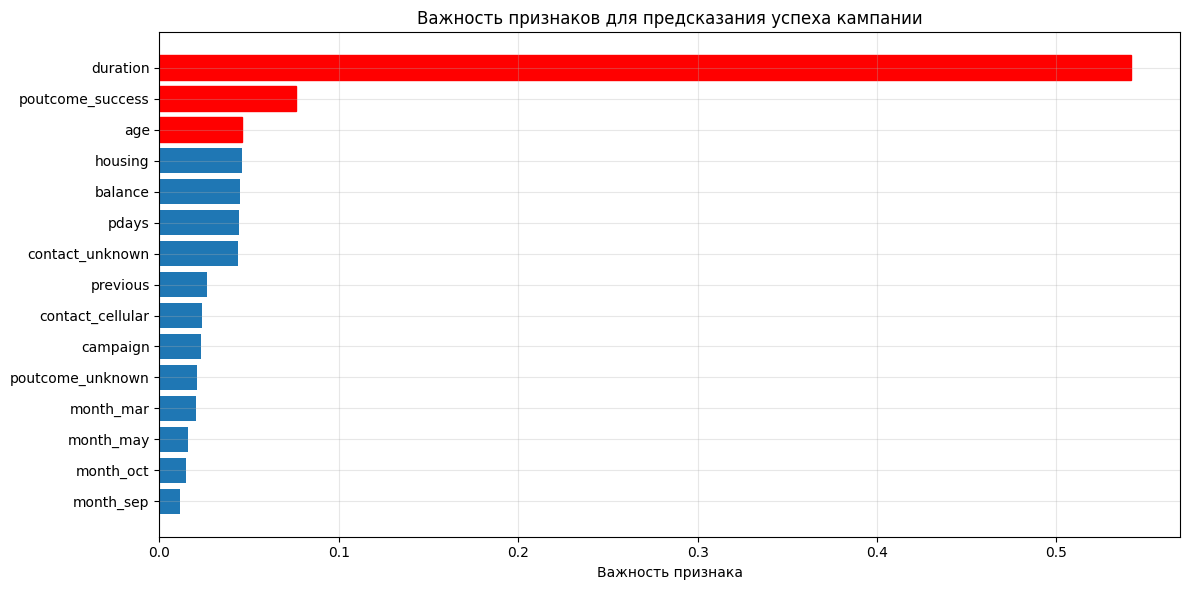

In [208]:
# оцените, какие признаки демонстрируют наибольшую  важность в модели градиентного бустинга
# используйте для классификации градиентный бустинг и сравните качество со случайным лесом
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Используем лучшую модель (предположим, Random Forest показал лучшие результаты)
best_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train_scaled, y_train)

# Получаем важность признаков
feature_importances = best_model.feature_importances_

# Создаем DataFrame с важностью признаков
importance_df = pd.DataFrame({
    'feature': selected_features,  # Используем выбранные 15 признаков
    'importance': feature_importances
})

# Сортируем по убыванию важности
importance_df = importance_df.sort_values('importance', ascending=False)

# Выбираем топ-3 признака
top_3_features = importance_df.head(3)
top_3_feature_names = top_3_features['feature'].tolist()

print("="*60)
print("ТОП-3 ВАЖНЕЙШИХ ПРИЗНАКА")
print("="*60)
print("\n№ | Признак | Важность")
print("-" * 40)
for i, (_, row) in enumerate(top_3_features.iterrows(), 1):
    print(f"{i} | {row['feature']:<25} | {row['importance']:.4f}")

# Визуализация важности признаков
plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(importance_df)), importance_df['importance'][::-1])
plt.yticks(range(len(importance_df)), importance_df['feature'][::-1])
plt.xlabel('Важность признака')
plt.title('Важность признаков для предсказания успеха кампании')
plt.grid(True, alpha=0.3)

# Подсвечиваем топ-3 признака
for i in range(3):
    bars[-(i+1)].set_color('red')

plt.tight_layout()
plt.show()


### Задания 6,7,8

In [212]:
import optuna

In [221]:
# реализуйте оптимизацию гиперпараметров с помощью Optuna
def optuna_rf(trial):
  # задаем пространства поиска гиперпараметров
  n_estimators = trial.suggest_int('n_estimators', 100, 200, 1)
  max_depth = trial.suggest_int('max_depth', 10, 30, 1)
  min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 10, 1)

  # создаем модель
  model = ensemble.RandomForestClassifier(n_estimators=n_estimators,
                                          max_depth=max_depth,
                                          min_samples_leaf=min_samples_leaf,
                                          random_state=42)
  # обучаем модель
  model.fit(X_train_scaled, y_train)
  score = metrics.f1_score(y_train, model.predict(X_train_scaled))

  return score
  %%time
# cоздаем объект исследования
# можем напрямую указать, что нам необходимо максимизировать метрику direction="maximize"
study = optuna.create_study(study_name="RandomForestClassifier", direction="maximize", )
# ищем лучшую комбинацию гиперпараметров n_trials раз
study.optimize(optuna_rf, n_trials=20)
# выводим результаты на обучающей выборке
print("Наилучшие значения гиперпараметров {}".format(study.best_params))
print("f1_score на обучающем наборе: {:.2f}".format(study.best_value))

[I 2025-12-28 17:25:09,998] A new study created in memory with name: RandomForestClassifier
[I 2025-12-28 17:25:11,004] Trial 0 finished with value: 0.8892014377246444 and parameters: {'n_estimators': 117, 'max_depth': 18, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.8892014377246444.
[I 2025-12-28 17:25:11,712] Trial 1 finished with value: 0.865657668903105 and parameters: {'n_estimators': 118, 'max_depth': 22, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.8892014377246444.
[I 2025-12-28 17:25:12,289] Trial 2 finished with value: 0.8521358159912377 and parameters: {'n_estimators': 120, 'max_depth': 20, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.8892014377246444.
[I 2025-12-28 17:25:13,106] Trial 3 finished with value: 0.8498672082487111 and parameters: {'n_estimators': 175, 'max_depth': 23, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.8892014377246444.
[I 2025-12-28 17:25:13,744] Trial 4 finished with value: 0.8857589984350548 and parameters: {'n_e

Наилучшие значения гиперпараметров {'n_estimators': 150, 'max_depth': 26, 'min_samples_leaf': 2}
f1_score на обучающем наборе: 0.93


In [222]:
# рассчитаем точность для тестовой выборки
model = ensemble.RandomForestClassifier(**study.best_params,random_state=42, )
model.fit(X_train_scaled, y_train)
y_train_pred = model.predict(X_train_scaled)
print("accuracy на тестовом наборе: {:.2f}".format(model.score(X_test_scaled, y_test)))
y_test_pred = model.predict(X_test_scaled)
print('f1_score на тестовом наборе: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))

accuracy на тестовом наборе: 0.83
f1_score на тестовом наборе: 0.82


In [223]:
%%time
# можем прододжить подбор, указав n_trials(любое число, которое добавится к предыдущим итерациям) 
study.optimize(optuna_rf, n_trials=10)

[I 2025-12-28 17:25:35,137] Trial 20 finished with value: 0.9197994987468672 and parameters: {'n_estimators': 127, 'max_depth': 22, 'min_samples_leaf': 2}. Best is trial 14 with value: 0.925148762918885.
[I 2025-12-28 17:25:36,078] Trial 21 finished with value: 0.9225705329153605 and parameters: {'n_estimators': 147, 'max_depth': 25, 'min_samples_leaf': 2}. Best is trial 14 with value: 0.925148762918885.
[I 2025-12-28 17:25:36,981] Trial 22 finished with value: 0.8928404305100608 and parameters: {'n_estimators': 145, 'max_depth': 28, 'min_samples_leaf': 3}. Best is trial 14 with value: 0.925148762918885.
[I 2025-12-28 17:25:38,081] Trial 23 finished with value: 0.923125097855018 and parameters: {'n_estimators': 155, 'max_depth': 25, 'min_samples_leaf': 2}. Best is trial 14 with value: 0.925148762918885.
[I 2025-12-28 17:25:39,044] Trial 24 finished with value: 0.8934975830344613 and parameters: {'n_estimators': 128, 'max_depth': 26, 'min_samples_leaf': 3}. Best is trial 14 with value: 

CPU times: total: 9.88 s
Wall time: 10.2 s


In [224]:
optuna.visualization.is_available()

True

In [225]:
optuna.visualization.plot_optimization_history(study, target_name="f1_score")

In [226]:
optuna.visualization.plot_contour(study, params=["max_depth", "n_estimators"],
                                  target_name="f1_score")